In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df =pd.read_csv("Downloads/student_performance_new.csv")

In [3]:
df.head()


,Sl.No.,USN,STUDENT NAME,Test I,Test II,Test III,Test Total,Test Result,Quiz 1,Quiz 2,Compensatory,Quiz,Quiz Result,Test + Quiz,Assignment,Unnamed: 15,Assignment Result,Result
0,1,1RV21MC001,ABHISHEK M,34,39,14,29.000000,1,4.0,6.0,10.0,16.0,1,45.000000,14,13,1,1
1,2,1RV21MC006,AJITH KUMAR K,30,33,27,30.000000,1,6.5,6.0,9.0,15.5,1,45.500000,14,13,0,0
2,3,1RV21MC009,AKASH E PUNAGIN,28,36,22,28.666667,1,7.0,5.0,NaN,12.0,1,40.666667,14,13,1,1
3,4,1RV21MC011,AMIT KUMAR,16,28,32,25.333333,1,3.0,2.0,10.0,13.0,1,38.333333,13,13,0,1
4,5,1RV21MC012,ANANDGOUDA PATIL,25,42,27,31.333333,1,6.0,5.0,10.0,16.0,1,47.333333,13,14,1,1


In [4]:
df.columns

Index(['Sl.No.', 'USN', 'STUDENT NAME', 'Test I ', 'Test II ', 'Test III',
       'Test Total ', 'Test Result ', 'Quiz 1', 'Quiz 2', 'Compensatory',
       'Quiz', 'Quiz Result ', 'Test + Quiz', 'Assignment ', 'Unnamed: 15',
       'Assignment Result ', 'Result'],
      dtype='object')

In [5]:
df.isna().sum()

Sl.No.                0
USN                   0
STUDENT NAME          0
Test I                0
Test II               0
Test III              0
Test Total            0
Test Result           0
Quiz 1                0
Quiz 2                0
Compensatory          1
Quiz                  0
Quiz Result           0
Test + Quiz           0
Assignment            0
Unnamed: 15           0
Assignment Result     0
Result                0
dtype: int64

In [6]:
df.columns=df.columns.str.strip()

In [7]:
X = df[['Test Result' , 'Quiz Result', 'Assignment Result']]
Y =df.Result

In [8]:
X.head()

,Test Result,Quiz Result,Assignment Result
0,1,1,1
1,1,1,0
2,1,1,1
3,1,1,0
4,1,1,1


In [9]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size = 0.2, random_state =42)
clf = DecisionTreeClassifier(criterion = 'entropy', splitter = 'random', random_state = 42, max_depth = 5)
clf.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'random'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
y_pred =clf.predict(x_test)


In [11]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Classification Report:",classification_report(y_test,y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.75      0.75      0.75         4

    accuracy                           0.82        11
   macro avg       0.80      0.80      0.80        11
weighted avg       0.82      0.82      0.82        11



[Text(0.5, 0.875, 'x[0] <= 0.196\nentropy = 0.933\nsamples = 43\nvalue = [28.0, 15.0]'),
 Text(0.25, 0.625, 'x[2] <= 0.723\nentropy = 0.414\nsamples = 24\nvalue = [22, 2]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'entropy = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.375, 0.375, 'x[1] <= 0.552\nentropy = 0.567\nsamples = 15\nvalue = [13, 2]'),
 Text(0.25, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.125, 'entropy = 0.592\nsamples = 14\nvalue = [12, 2]'),
 Text(0.75, 0.625, 'x[2] <= 0.724\nentropy = 0.9\nsamples = 19\nvalue = [6, 13]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'entropy = 0.65\nsamples = 6\nvalue = [5, 1]'),
 Text(0.875, 0.375, 'entropy = 0.391\nsamples = 13\nvalue = [1, 12]')]

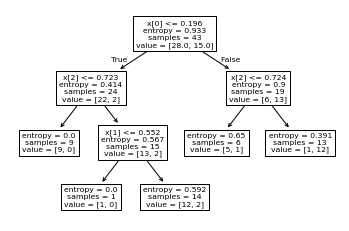

In [12]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [32]:
user_test = int(input("Enter test result(0 or 1):"))
user_quiz = int(input("Enter Quiz Result(0 or 1):"))
user_assignment = int(input("Enter assignment result(0 or 1):"))

Enter test result(0 or 1):1
Enter Quiz Result(0 or 1):0
Enter assignment result(0 or 1):1


In [33]:
user_x =[[user_test, user_quiz, user_assignment]]
prediction=clf.predict(user_x)

/home/dsbatch2/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [34]:
if prediction[0] == 1:
    print("Pediction:PASS")
else:
    print("Prediction:FAIL")

Pediction:PASS
